# TrkQualTrain.ipynb

The notebook to train the TrkQual algorithm. Note that this runs on TrkAna v4 trees

## User-defined parameters

Here are some common parameters that a new user may want to change

In [8]:
# User-defined parameters
output_modelname = 'TrkQual_xgb_v2.0'
training_dataset_filename = "/Users/malikfarouh/Documents/ML_workspace/data/trkqual_tree_v2.0_training.root"
training_dataset_dirname = ""
training_dataset_treename = "trkqualtree"

In [9]:
import uproot
import awkward as ak
from math import sqrt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, roc_curve, auc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
#To save the XGB model
import joblib

## Some useful functions

Here we declare some useful functions that will be used

### add_useful_columns
The ```add_useful_columns``` function is used to add some new columns to the awkward array

In [10]:
def add_useful_columns(batch):
    # Calculate magnitude of the momenta
    batch['trk_ent.mom'] = (batch['trk_ent.mom.fCoordinates.fX']**2 + batch['trk_ent.mom.fCoordinates.fY']**2 + batch['trk_ent.mom.fCoordinates.fZ']**2)**0.5
    batch['trk_ent_mc.mom'] = (batch['trk_ent_mc.mom.fCoordinates.fX']**2 + batch['trk_ent_mc.mom.fCoordinates.fY']**2 + batch['trk_ent_mc.mom.fCoordinates.fZ']**2)**0.5
    
    # For masks
    #batch['ent_fit_is_highmom'] = ak.flatten(ak.any( (batch['demfit.mom']>80) & (batch['demfit.sid']==0), axis=-1, keepdims=True))
    
    # For training features
    batch['trk.factive'] = batch['trk.nactive'] / batch['trk.nhits']
    batch['trk.fambig'] = batch['trk.nnullambig'] / batch['trk.nactive']
    batch['trk.fstraws'] = batch['trk.nmatactive'] / batch['trk.nactive']

### plot_loss

The ```plot_loss``` function will be used later after the model is trained

In [4]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss (training)')
  plt.plot(history.history['val_loss'], label='loss (validation)')
  plt.ylim([0, 2])
  plt.xlabel('Epoch')
  plt.ylabel('Error')
  plt.legend()
  plt.grid(True)

### We start filling some arrays with the data we want from the TrkAna 
### Now we organize our training features into the correct shape

In [11]:
'''# We will put the variables we want into numpy arrays
trk_ent_mom=[] # reco momentum at tracker entrance
trk_ent_mc_mom=[] # MC true momentum at tracker entrance
# The variables we need for the features we will train on

nactive=[]
factive=[]
t0err=[]
momerr=[]
fambig=[]
fitcon=[]
fstraws=[]

counter=0

trkqual_tree = uproot.open(training_dataset_filename+":"+training_dataset_treename)
print(training_dataset_filename.split('/')[-1].strip('\n') + ": "+str(trkqual_tree.num_entries)+" entries")
# Iterate through the entries in the file
for batch, report in trkqual_tree.iterate(step_size="10 MB", report=True, library='ak'):
    # Make some aliases for new columns
    add_useful_columns(batch)
    
    # Get the cut masks: one for the track dimensions (rows in the trkana tree), and one for the fit dimensions (we get multiple fits per track)
    track_mask = (batch['trk.status']>0) & (batch['trk.goodfit']==1) & ~np.isnan(batch['trk_ent_pars.t0err']) & (batch['trk_sim.startCode']==173)#167)) # & (batch['has_ent_fit']==True) & (batch['has_ent_mc']==True) & (batch['ent_fit_is_highmom']==True)
    #sim_mask = (batch['demmcsim.gen']==167)
    #fit_mask = (batch['.sid']==0) 
    #mc_mask = (batch['demmcvd.sid']==0) # we want the fit momentum at the entrance
            
    # Here we keep on appending to the arrays
    trk_ent_mom = np.append(trk_ent_mom, (batch['trk_ent.mom'][track_mask]).to_numpy())
    trk_ent_mc_mom = np.append(trk_ent_mc_mom, (batch['trk_ent_mc.mom'][track_mask]).to_numpy())
                
    nactive = np.append(nactive, (batch['trk.nactive'][track_mask]).to_numpy())
    factive = np.append(factive, (batch['trk.factive'][track_mask]).to_numpy())
    fambig = np.append(fambig, (batch['trk.fambig'][track_mask]).to_numpy())
    fstraws = np.append(fstraws, (batch['trk.fstraws'][track_mask]).to_numpy())
    #print(nactive)
            
    t0err = np.append(t0err, batch['trk_ent_pars.t0err'][track_mask].to_numpy())   
    fitcon = np.append(fitcon, (batch['trk.fitcon'][track_mask]).to_numpy())
    momerr = np.append(momerr, (batch['trk_ent.momerr'][track_mask]).to_numpy())

# Define high-quality and low-quality tracks
mom_res = trk_ent_mom - trk_ent_mc_mom
high_qual = (mom_res>-0.25) & (mom_res<0.25)
low_qual = (mom_res>0.7)

print("Batch length:", len(batch['trk.status']))
print("trk.status > 0:", np.sum(batch['trk.status'] > 0))
print("trk.goodfit == 1:", np.sum(batch['trk.goodfit'] == 1))
print("~np.isnan(trk_ent_pars.t0err):", np.sum(~np.isnan(batch['trk_ent_pars.t0err'])))
print("trk_sim.startCode == 167:", np.sum(batch['trk_sim.startCode'] == 167))
print(np.unique(batch['trk_sim.startCode']))
# Since this cell takes a while, we'll print to say that we're done
print("Done!")'''

'# We will put the variables we want into numpy arrays\ntrk_ent_mom=[] # reco momentum at tracker entrance\ntrk_ent_mc_mom=[] # MC true momentum at tracker entrance\n# The variables we need for the features we will train on\n\nnactive=[]\nfactive=[]\nt0err=[]\nmomerr=[]\nfambig=[]\nfitcon=[]\nfstraws=[]\n\ncounter=0\n\ntrkqual_tree = uproot.open(training_dataset_filename+":"+training_dataset_treename)\nprint(training_dataset_filename.split(\'/\')[-1].strip(\'\n\') + ": "+str(trkqual_tree.num_entries)+" entries")\n# Iterate through the entries in the file\nfor batch, report in trkqual_tree.iterate(step_size="10 MB", report=True, library=\'ak\'):\n    # Make some aliases for new columns\n    add_useful_columns(batch)\n\n    # Get the cut masks: one for the track dimensions (rows in the trkana tree), and one for the fit dimensions (we get multiple fits per track)\n    track_mask = (batch[\'trk.status\']>0) & (batch[\'trk.goodfit\']==1) & ~np.isnan(batch[\'trk_ent_pars.t0err\']) & (batch[\

### Shorter cell from the one above, more efficient.

In [12]:
def load_training_arrays_batched(filepath, treename, step_size="50 MB", start_code=173):
    tree = uproot.open(f"{filepath}:{treename}")
    print(f"{filepath.split('/')[-1]}: {tree.num_entries} entries")

    out = {k: [] for k in [
        "trk_ent_mom", "trk_ent_mc_mom", "nactive", "factive",
        "fambig", "fstraws", "t0err", "fitcon", "momerr"
    ]}

    needed = [
        # mask inputs
        "trk.status", "trk.goodfit", "trk_ent_pars.t0err", "trk_sim.startCode",

        # direct outputs / raw
        "trk.nactive", "trk.fitcon", "trk_ent.momerr",

        # required by add_useful_columns for derived feature columns
        "trk.nhits", "trk.nnullambig", "trk.nmatactive",

        # required by add_useful_columns for momentum magnitudes
        "trk_ent.mom.fCoordinates.fX",
        "trk_ent.mom.fCoordinates.fY",
        "trk_ent.mom.fCoordinates.fZ",
        "trk_ent_mc.mom.fCoordinates.fX",
        "trk_ent_mc.mom.fCoordinates.fY",
        "trk_ent_mc.mom.fCoordinates.fZ",
    ]

    for batch in tree.iterate(filter_name=needed, step_size=step_size, library="ak"):
        add_useful_columns(batch)

        t0 = batch["trk_ent_pars.t0err"]
        t0_np = ak.to_numpy(t0)  # 1D numeric after your selection style
        valid_t0 = np.isfinite(t0_np)   # handles NaN and inf
        mask = (
            (batch["trk.status"] > 0)
            & (batch["trk.goodfit"] == 1)
            & ~ak.is_none(t0)
            & valid_t0
            & (batch["trk_sim.startCode"] == start_code)
        )

        out["trk_ent_mom"].append(ak.to_numpy(batch["trk_ent.mom"][mask]))
        out["trk_ent_mc_mom"].append(ak.to_numpy(batch["trk_ent_mc.mom"][mask]))
        out["nactive"].append(ak.to_numpy(batch["trk.nactive"][mask]))
        out["factive"].append(ak.to_numpy(batch["trk.factive"][mask]))
        out["fambig"].append(ak.to_numpy(batch["trk.fambig"][mask]))
        out["fstraws"].append(ak.to_numpy(batch["trk.fstraws"][mask]))
        out["t0err"].append(ak.to_numpy(t0[mask]))
        out["fitcon"].append(ak.to_numpy(batch["trk.fitcon"][mask]))
        out["momerr"].append(ak.to_numpy(batch["trk_ent.momerr"][mask]))

    for k, chunks in out.items():
        out[k] = np.concatenate(chunks) if chunks else np.array([], dtype=np.float64)

    mom_res = out["trk_ent_mom"] - out["trk_ent_mc_mom"]
    out["high_qual"] = (mom_res > -0.25) & (mom_res < 0.25)
    out["low_qual"]  = mom_res > 0.7

    print(f"Done. Selected tracks: {len(out['trk_ent_mom'])}")
    return out

In [13]:
data_dict = load_training_arrays_batched(training_dataset_filename, training_dataset_treename)

(trk_ent_mom, trk_ent_mc_mom, nactive, factive, fambig,
 fstraws, t0err, fitcon, momerr, high_qual, low_qual) = (
    data_dict["trk_ent_mom"], data_dict["trk_ent_mc_mom"], data_dict["nactive"], data_dict["factive"],
    data_dict["fambig"], data_dict["fstraws"], data_dict["t0err"], data_dict["fitcon"],
    data_dict["momerr"], data_dict["high_qual"], data_dict["low_qual"]
)
print(f"N tracks: {len(trk_ent_mom)} | high: {high_qual.sum()} | low: {low_qual.sum()}")

trkqual_tree_v2.0_training.root: 452686 entries
Done. Selected tracks: 452686
N tracks: 452686 | high: 303991 | low: 13449


In [14]:
'''input_dataset=np.empty
temp = np.empty
temp = np.vstack((nactive, factive, t0err, fambig, fitcon, momerr, fstraws)).T
#print(temp)  Not included in the old one
if input_dataset is np.empty:
    input_dataset = temp
else:
    input_dataset = np.concatenate((input_dataset, temp))

input_var_names = ["nactive", "factive", "t0err", "fambig", "fitcon", "momerr", "fstraws"]
n_input_vars = len(input_dataset[0])'''

'input_dataset=np.empty\ntemp = np.empty\ntemp = np.vstack((nactive, factive, t0err, fambig, fitcon, momerr, fstraws)).T\n#print(temp)  Not included in the old one\nif input_dataset is np.empty:\n    input_dataset = temp\nelse:\n    input_dataset = np.concatenate((input_dataset, temp))\n\ninput_var_names = ["nactive", "factive", "t0err", "fambig", "fitcon", "momerr", "fstraws"]\nn_input_vars = len(input_dataset[0])'

In [15]:
input_var_names = ["nactive", "factive", "t0err", "fambig", "fitcon", "momerr", "fstraws"]

# Build matrix safely from the data dictionary
input_dataset = np.column_stack([data_dict[k] for k in input_var_names])
n_input_vars = len(input_var_names)

print(f"Matrix built successfully! Shape: {input_dataset.shape}")

Matrix built successfully! Shape: (452686, 7)


### Now we plot the momentum resolution of the training sample with the high-quality and low-quality tracks highlighted

Text(0, 0.5, 'Number of Tracks')

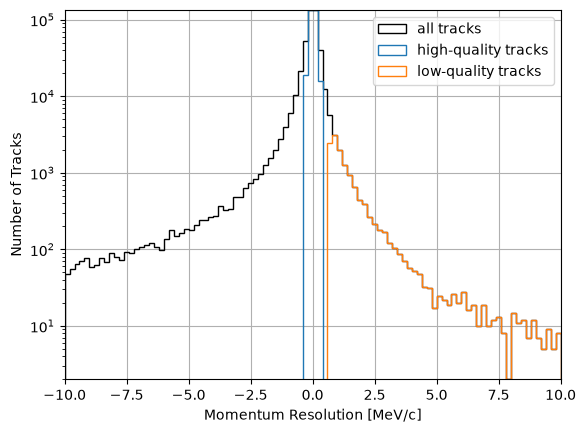

In [16]:
mom_res = trk_ent_mom - trk_ent_mc_mom
min_mom_res=-10
max_mom_res=10
n_mom_res_bins=100

fig, ax = plt.subplots(1, 1)
bins, counts, patches = ax.hist(mom_res, bins=n_mom_res_bins, range=(min_mom_res,max_mom_res), log=True, histtype='step', color='black', label='all tracks')
bins, counts, patches = ax.hist(mom_res[high_qual], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res), log=True, histtype='step', label='high-quality tracks')
bins, counts, patches = ax.hist(mom_res[low_qual], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res), log=True, histtype='step', label='low-quality tracks')
ax.legend()
ax.margins(0)
ax.grid(True)
ax.set_xlabel("Momentum Resolution [MeV/c]")
ax.set_ylabel("Number of Tracks")

Text(0, 0.5, 'Number of Tracks')

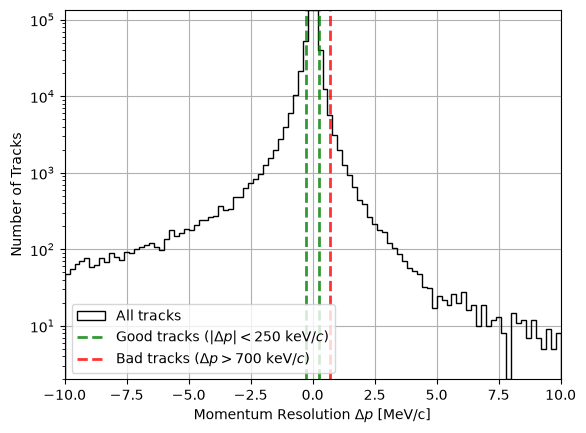

In [17]:
fig, ax = plt.subplots(1,1)

ax.hist(
    mom_res,
    bins=n_mom_res_bins,
    range=(min_mom_res, max_mom_res),
    log=True,
    histtype='step',
    color='black',
    label='All tracks'
)

# Good tracks: |ΔP| < 250 keV/c = 0.25 MeV/c
ax.axvline(x=0.25, color='green', linestyle='--', linewidth=2, alpha=0.8)
ax.axvline(x=-0.25, color='green', linestyle='--', linewidth=2, alpha=0.8,
           label=r'Good tracks ($|\Delta p| < 250$ keV/$c$)')

# Bad tracks: ΔP > 700 keV/c = 0.7 MeV/c (positive tail only)
ax.axvline(x=0.7, color='red', linestyle='--', linewidth=2, alpha=0.8,
           label=r'Bad tracks ($\Delta p > 700$ keV/$c$)')

ax.legend()
ax.margins(0)
ax.grid(True)
ax.set_xlabel(r"Momentum Resolution $\Delta p$ [MeV/c]")
ax.set_ylabel("Number of Tracks")

### Here we plot all the training features. Note that we have used ```density=True``` so each histogram is normalized to unit area

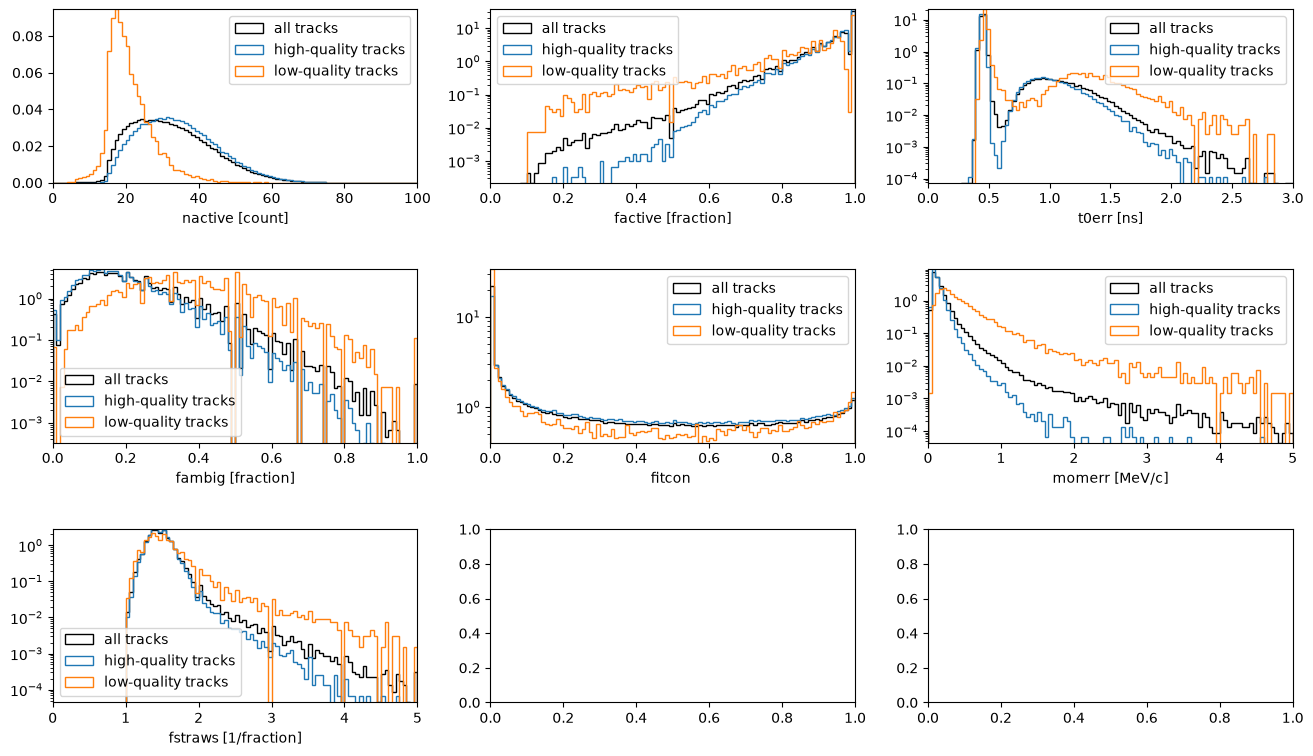

In [18]:
input_var_names = ["nactive", "factive", "t0err", "fambig", "fitcon", "momerr", "fstraws"]
input_dataset = np.column_stack([data_dict[k] for k in input_var_names])
n_input_vars = len(input_var_names)

fig, axs = plt.subplots(3, 3, figsize=(16,9))
fig.subplots_adjust(hspace=.5)
x_mins=[0, 0, 0, 0, 0, 0, 0]
x_maxs=[100, 1, 3, 1, 1, 5, 5]
log_ys=[False, True, True, True, True, True, True]
#log_ys=[False, False, False, False, False, False, False]
units=['[count]', '[fraction]', '[ns]', '[fraction]', '', '[MeV/c]', '[1/fraction]']
density=True
for i_var in range(0, n_input_vars):
    bins, counts, patches = axs.flatten()[i_var].hist(input_dataset[:,i_var], bins=100, range=(x_mins[i_var],x_maxs[i_var]), histtype='step', color='black', log=log_ys[i_var], label='all tracks', density=density)
    bins, counts, patches = axs.flatten()[i_var].hist(input_dataset[:,i_var][high_qual], bins=100, range=(x_mins[i_var],x_maxs[i_var]), histtype='step', log=log_ys[i_var], label='high-quality tracks', density=density)
    bins, counts, patches = axs.flatten()[i_var].hist(input_dataset[:,i_var][low_qual], bins=100, range=(x_mins[i_var],x_maxs[i_var]), histtype='step', log=log_ys[i_var], label='low-quality tracks', density=density)
    axs.flatten()[i_var].set_xlabel(input_var_names[i_var]+" "+units[i_var])
    axs.flatten()[i_var].margins(0)
    axs.flatten()[i_var].legend()

### Now we balance the inputs since we don't have that many low-quality tracks to train on

In [19]:
# In this cell x_ variables are features, and y_ are the output results
min_len = min(len(input_dataset[high_qual]), len(input_dataset[low_qual]))

# Get the INDICES of high and low quality tracks
high_qual_indices = np.where(high_qual)[0][:min_len]
low_qual_indices = np.where(low_qual)[0][:min_len]

# Create balanced dataset
x_high_qual_dataset = input_dataset[high_qual][:min_len]
x_low_qual_dataset = input_dataset[low_qual][:min_len]
x_balanced_input = np.concatenate((x_high_qual_dataset, x_low_qual_dataset))

# Set 1 to be high quality, and 0 to be low quality
y_balanced_input = np.concatenate((np.ones(x_high_qual_dataset.shape[0]), np.zeros(x_low_qual_dataset.shape[0])))

# Track the original indices
balanced_indices = np.concatenate((high_qual_indices, low_qual_indices))

# Split the dataset into train and test samples, keeping track of indices
x_train, x_test, y_train, y_test, train_indices, test_indices = train_test_split(
    x_balanced_input, y_balanced_input, balanced_indices, test_size=0.5, random_state=42
)

# Further split the test sample into testing and validation samples
x_test, x_valid, y_test, y_valid, test_indices, valid_indices = train_test_split(
    x_test, y_test, test_indices, test_size=0.5, random_state=42
)

print("N train = "+str(len(x_train)) + ", N test = "+str(len(x_test)) + ", N valid = "+str(len(x_valid)))

N train = 13449, N test = 6724, N valid = 6725


### Here we plot the features for each of the training, testing, and validation samples. All these plots should look similar

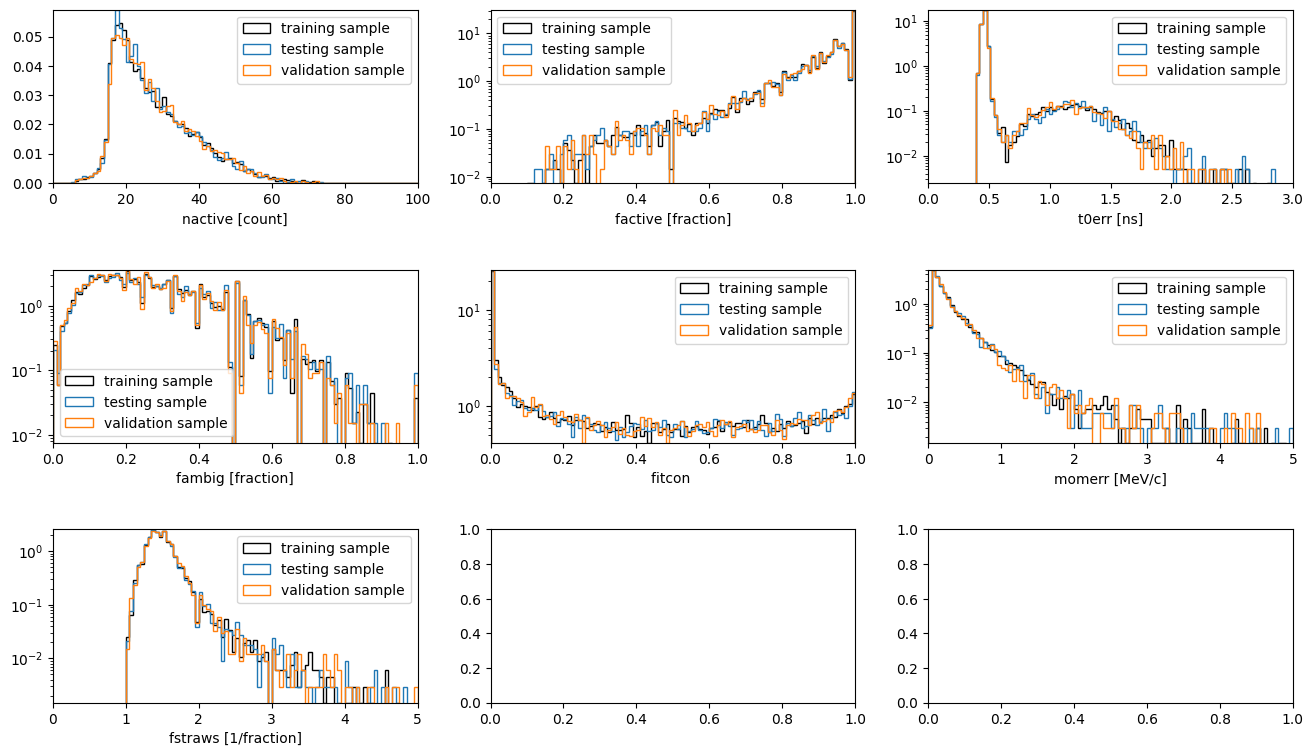

In [ ]:
fig, axs = plt.subplots(3, 3, figsize=(16,9))
fig.subplots_adjust(hspace=.5)
for i_var in range(0, n_input_vars):
    bins, counts, patches = axs.flatten()[i_var].hist(x_train[:,i_var], bins=100, range=(x_mins[i_var],x_maxs[i_var]), histtype='step', color='black', log=log_ys[i_var], label='training sample', density=True)
    bins, counts, patches = axs.flatten()[i_var].hist(x_test[:,i_var], bins=100, range=(x_mins[i_var],x_maxs[i_var]), histtype='step', log=log_ys[i_var], label='testing sample', density=True)
    bins, counts, patches = axs.flatten()[i_var].hist(x_valid[:,i_var], bins=100, range=(x_mins[i_var],x_maxs[i_var]), histtype='step', log=log_ys[i_var], label='validation sample', density=True)
    axs.flatten()[i_var].set_xlabel(input_var_names[i_var]+" "+units[i_var])
    axs.flatten()[i_var].margins(0)
    axs.flatten()[i_var].legend()

Here we now build the model and do the training. Here we are copying what was done in the old TrkQual. Namely:
 - N, N-1 neurons in the hidden layers
 - sigmoid activation functions
 - no dropout layers

### Now get the predicted values for the input dataset (ideally, this would be a separate dataset)

## Create Full Datasets & Define Your Loop (The Setup)

In [20]:
# Build full labeled dataset from your masks
x_full = np.concatenate([input_dataset[high_qual], input_dataset[low_qual]])
y_full = np.concatenate([
    np.ones(np.sum(high_qual), dtype=np.int32),
    np.zeros(np.sum(low_qual), dtype=np.int32)
])

# Sanity checks
assert len(high_qual) == len(input_dataset), "high_qual length mismatch"
assert len(low_qual) == len(input_dataset), "low_qual length mismatch"
assert x_full.shape[0] == y_full.shape[0], "x_full/y_full size mismatch"

print(f"x_full shape: {x_full.shape}")
print(f"y_full counts -> high: {(y_full==1).sum()}, low: {(y_full==0).sum()}")

# Experiment setup
tree_counts = [500]   # try [100, 200, 500, 800]
N = len(y_valid)

final_accs = []
final_uncertainties = []
final_errors = []
final_logloss = []
models = []

x_full shape: (317440, 7)
y_full counts -> high: 303991, low: 13449


## Execute the XGBoost Model Training Loop

In [21]:
for n_rounds in tree_counts:
    print(f"\nTraining XGBClassifier with n_estimators={n_rounds}")

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        max_depth=2,          
        learning_rate=0.04,
        n_estimators=n_rounds,
        subsample=1.0,
        colsample_bytree=1.0,
        reg_lambda=0.5,
        reg_alpha=0.5,
        gamma=0.1,
        random_state=42,
    )

    # Early stopping picks best tree count up to n_rounds
    model.fit(
        x_train, y_train,
        eval_set=[(x_train, y_train), (x_valid, y_valid)],
        verbose=False
    )

    y_pred_prob = model.predict_proba(x_valid)[:, 1]
    y_pred = (y_pred_prob > 0.5).astype(int)

    ll = log_loss(y_valid, y_pred_prob)
    acc = accuracy_score(y_valid, y_pred)
    err = 1.0 - acc
    sigma = np.sqrt(acc * (1.0 - acc) / N)

    final_logloss.append(ll)
    final_accs.append(acc)
    final_errors.append(err)
    final_uncertainties.append(sigma)
    models.append(model)

    print(f"  LogLoss={ll:.4f} | Acc={acc:.4f} ± {sigma:.4f} | Err={err:.4f}")

# keep last model outputs for perturbation comparison
best_model = models[np.argmax(final_accs)]
y_pred_prob_original = best_model.predict_proba(x_full)[:, 1]
print("\nTraining complete.")


Training XGBClassifier with n_estimators=500
  LogLoss=0.2945 | Acc=0.8739 ± 0.0040 | Err=0.1261

Training complete.


## Generate and Save Evaluation Visualizations

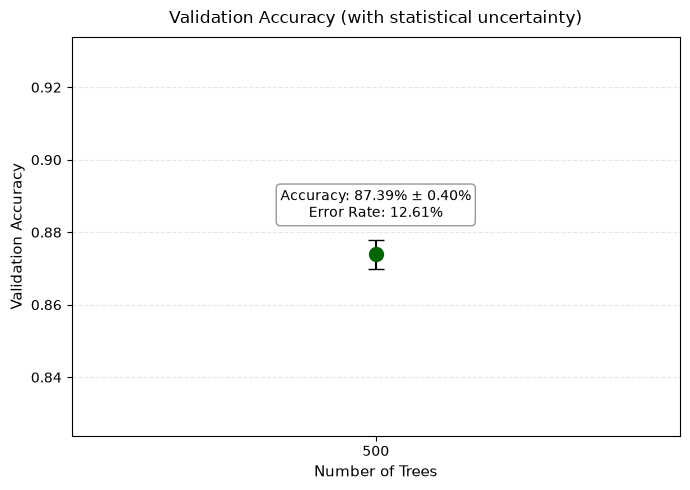

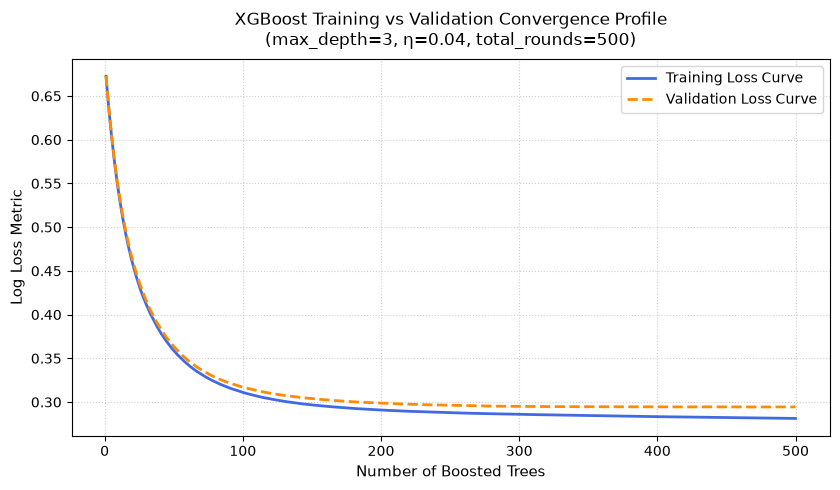

In [22]:
# GRAPH 1: SINGLE MODEL VALIDATION ACCURACY WITH ERROR BAR 
fig, ax = plt.subplots(figsize=(7, 5))

n_trees_used = model.get_params()["n_estimators"]
acc = final_accs[-1]
sig = final_uncertainties[-1]
err = final_errors[-1]
x = [0]
ax.set_xticks([0], labels=[str(n_trees_used)])

# Draw clean statistical error point
ax.errorbar(
    x, [acc], yerr=[sig], 
    fmt='o', markersize=10, capsize=6, 
    color='darkgreen', ecolor='black', elinewidth=1.5, label="Model Baseline"
)

# Clean dynamic y-axis padding to make space for text
ymin = max(0, acc - 0.05)
ymax = min(1, acc + 0.06)
ax.set_ylim(ymin, ymax)

ax.set_xlabel("Number of Trees", fontsize=11)
ax.set_ylabel("Validation Accuracy", fontsize=11)
ax.set_title("Validation Accuracy (with statistical uncertainty)", fontsize=12, pad=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Floating text block above the point to prevent any text clipping or bleeding
ax.text(
    0, acc + sig + 0.005, 
    f"Accuracy: {acc:.2%} ± {sig:.2%}\nError Rate: {err:.2%}", 
    ha='center', va='bottom', fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
)

plt.tight_layout()
plt.show()

# GRAPH 2: PROGRESSIVE LOG LOSS CONVERGENCE
# Fetching the execution history directly from the trained model object
evals_dict = model.evals_result()

train_loss = evals_dict['validation_0']['logloss']
valid_loss = evals_dict['validation_1']['logloss']
epochs_range = range(1, len(train_loss) + 1)

plt.figure(figsize=(8.5, 5))
plt.plot(epochs_range, train_loss, label='Training Loss Curve', color='royalblue', linewidth=2)
plt.plot(epochs_range, valid_loss, label='Validation Loss Curve', color='darkorange', linewidth=2, linestyle='--')

plt.ylabel('Log Loss Metric', fontsize=11)
plt.xlabel('Number of Boosted Trees', fontsize=11)
plt.title(f"XGBoost Training vs Validation Convergence Profile\n(max_depth=3, η=0.04, total_rounds={len(train_loss)})", fontsize=12, pad=10)

plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

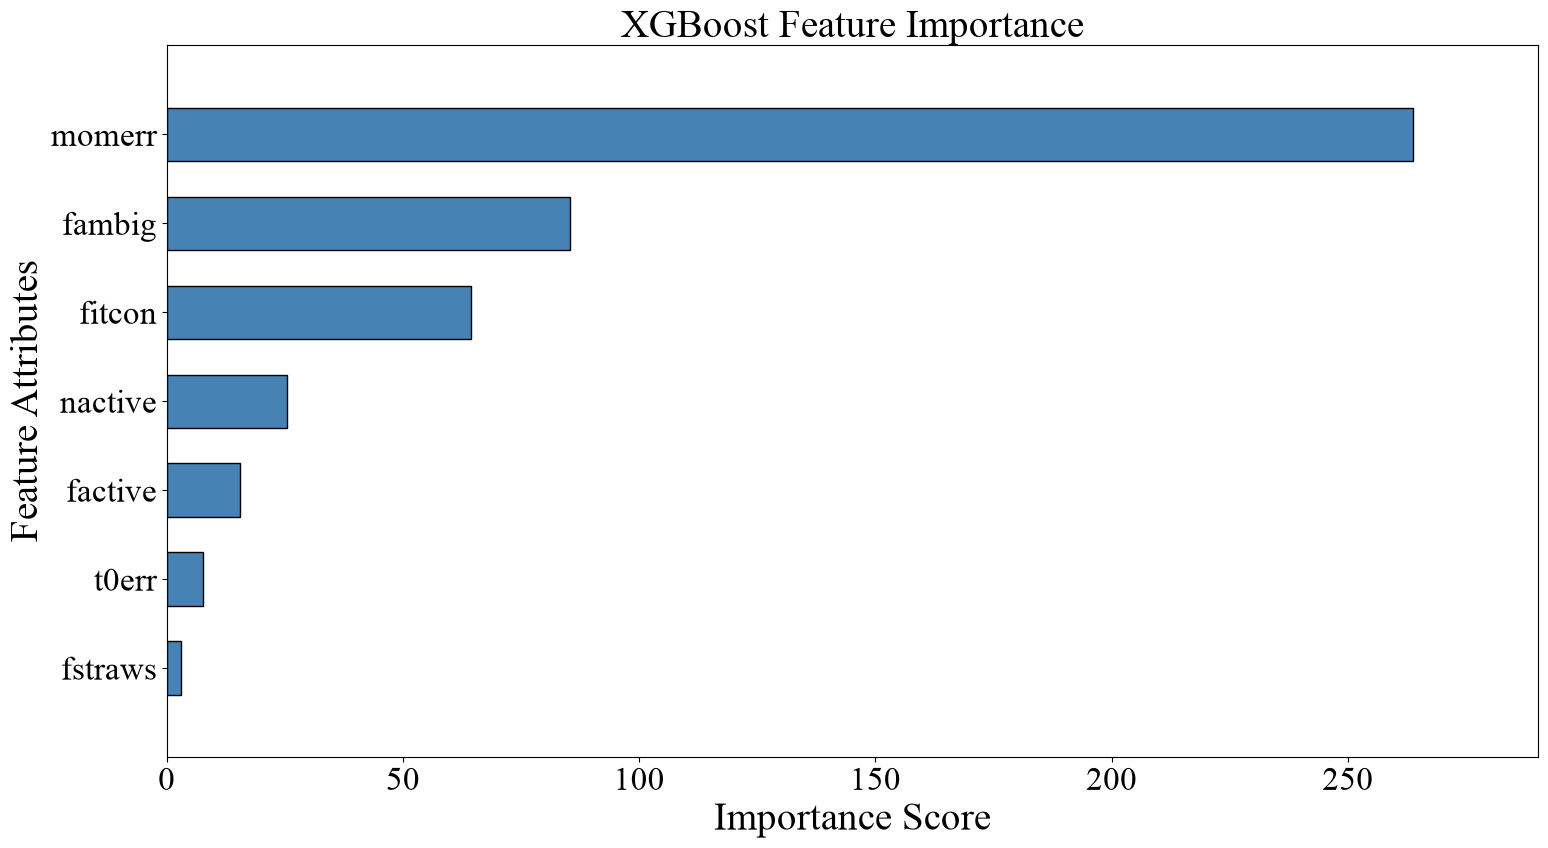

In [38]:
# 1. Attach the variable names from the top cell directly to the booster
booster = model.get_booster()
booster.feature_names = input_var_names

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman', 'Times New Roman']
plt.rcParams['pdf.fonttype'] = 42

# Scale font sizes up Figures  after LaTeX
plt.rcParams.update({
    'font.size': 24,
    'axes.labelsize': 28,
    'axes.titlesize': 28,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'legend.fontsize': 16
})

# 2. Plot the importances 
fig, ax = plt.subplots(figsize=(16, 9))
xgb.plot_importance(booster, importance_type='gain', ax=ax, grid=False, show_values=False, color='steelblue', edgecolor='black', height=0.6)

# Refine labels for the technical note
'''ax.set_title('XGBoost Feature Importance', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature Attributes', fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=11)'''

ax.set_title('XGBoost Feature Importance')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature Attributes')
ax.tick_params(axis='both')
plt.savefig("/Users/malikfarouh/Documents/latex_notes/2026-08_TrkQual_Robustness_BDT/images/importance_plot.pdf")
plt.tight_layout()
plt.show()

### Showing the splits according to the used feature

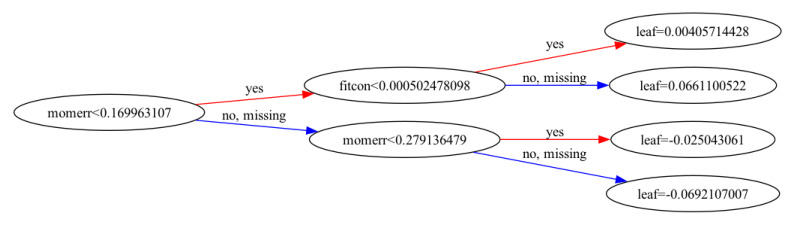

In [ ]:
# Create a feature map file
with open('fmap.txt', 'w') as f:
    for idx, name in enumerate(input_var_names):
        f.write(f"{idx}\t{name}\tq\n")

# Now plot with the feature map
for i in range(1):
    plt.rcParams['figure.figsize'] = [10, 10] 
    xgb.plot_tree(model, num_trees=i, rankdir="LR", fmap='fmap.txt')
    plt.show()

### Now we save the model

In [ ]:
trkqual = best_model.predict(input_dataset).astype(int)
trkqual_prob = best_model.predict_proba(input_dataset)[:, 1]

assert len(trkqual) == len(input_dataset)

model_filename = "xgb_trkqual_best_model_v1.joblib"
joblib.dump(best_model, model_filename)

print(f"Generated predictions for {len(trkqual)} tracks.")
print(f"Saved best model as: {model_filename}")

Generated predictions for 452686 tracks.
Saved best model as: xgb_trkqual_best_model_v1.joblib


## Some Validation Plots
### Here is the loss as a function of epoch for the training and validation datasets

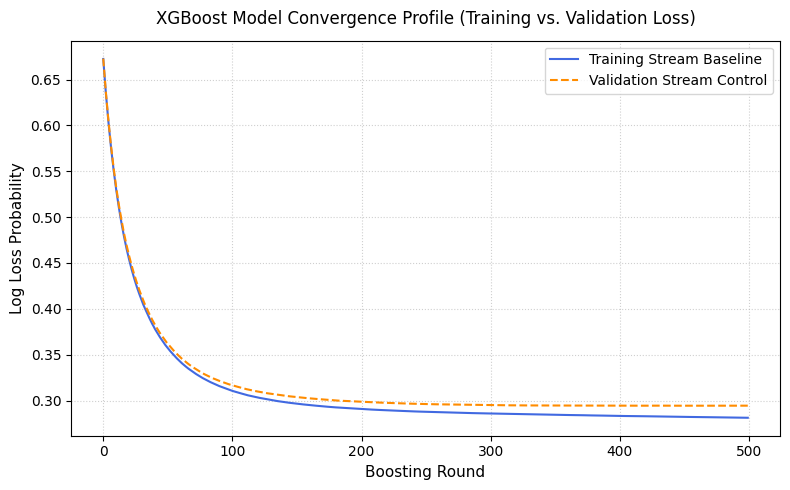

In [ ]:
def plot_loss(evals_result):
    """
    Plots training and validation loss from XGBoost.
    Maps the internal numbered tracking profiles to explicit, human-readable labels.
    """

    training_loss_history = evals_result['validation_0']['logloss']
    validation_loss_history = evals_result['validation_1']['logloss']
    
    plt.figure(figsize=(8, 5))
    plt.plot(training_loss_history, label="Training Stream Baseline", color='royalblue', linewidth=1.5)
    plt.plot(validation_loss_history, label="Validation Stream Control", color='darkorange', linewidth=1.5, linestyle='--')
    
    plt.xlabel("Boosting Round", fontsize=11)
    plt.ylabel("Log Loss Probability", fontsize=11)
    plt.title("XGBoost Model Convergence Profile (Training vs. Validation Loss)", fontsize=12, pad=12)
    
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Run the function using the best model configuration
plot_loss(best_model.evals_result())


## ROC Curve Analysis
### Here we get the ROC curve, as well as the cut value that rejects 99% of low-quality tracks. (For a real analysis, we would find a different optimization procedure)

500 trees: trkqual_cut=0.9200000166893005, signal eff=57.0%, background rej=99.0%


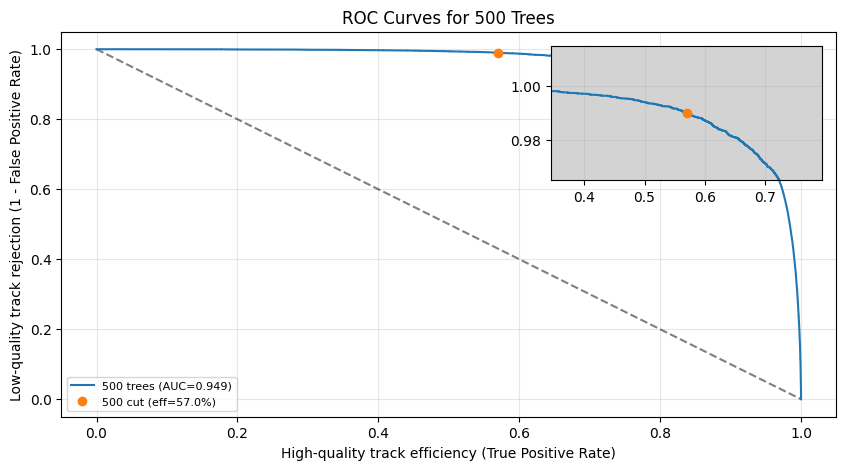

In [ ]:
# Tree counts to evaluate
tree_counts = [500] #1000
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot([0, 1], [1, 0], 'k--', alpha=0.5)  # diagonal
roc_data = {}
for n_rounds in tree_counts:
    # Predict using only the first n_rounds trees
    y_pred_prob = best_model.predict_proba(x_full, iteration_range=(0, n_rounds))[:, 1]  # get probability of class 1
    
    # Compute ROC
    fpr, tpr, thresholds = roc_curve(y_full, y_pred_prob, pos_label=1)
    auc_score = auc(fpr, tpr)
    
    # Cut point for 99% background rejection
    rej_target = 0.99
    indices = np.where(1 - fpr >= rej_target)[0]
    cut_idx = indices[-1] if len(indices) > 0 else 0
    sig_eff = tpr[cut_idx]
    trkqual_cut = round(thresholds[cut_idx], 2)
    
    roc_data[n_rounds] = (fpr, tpr, cut_idx)
    
    print(f"{n_rounds} trees: trkqual_cut={trkqual_cut}, "
          f"signal eff={sig_eff*100:.1f}%, background rej={(1-fpr[cut_idx])*100:.1f}%")
    
    # Plot main ROC, Legend shows AUC and signal efficiency
    ax.plot(tpr, 1 - fpr, label=f"{n_rounds} trees (AUC={auc_score:.3f})")
    ax.plot(tpr[cut_idx], 1 - fpr[cut_idx], 'o', label=f"{n_rounds} cut (eff={sig_eff*100:.1f}%)")
# Main plot settings
ax.set_xlabel("High-quality track efficiency (True Positive Rate)")
ax.set_ylabel("Low-quality track rejection (1 - False Positive Rate)")
ax.set_title("ROC Curves for 500 Trees")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
# Zoom inset around cut points
axins = inset_axes(ax, width="35%", height="35%", loc='upper right', borderpad=1.0)
axins.set_facecolor("lightgray")
for n_rounds in tree_counts:
    fpr, tpr, cut_idx = roc_data[n_rounds]
    axins.plot(tpr, 1 - fpr)
    axins.plot(tpr[cut_idx], 1 - fpr[cut_idx], 'o')
# Zoom ranges around mean cut points
cut_tpr = [roc_data[n][1][roc_data[n][2]] for n in tree_counts]
cut_rej = [1 - roc_data[n][0][roc_data[n][2]] for n in tree_counts]
mean_tpr = np.mean(cut_tpr)
mean_rej = np.mean(cut_rej)
zoom_x = 0.45 #0.20
zoom_y = 0.05
axins.set_xlim(mean_tpr - zoom_x/2, mean_tpr + zoom_x/2)
axins.set_ylim(mean_rej - zoom_y/2, mean_rej + zoom_y/2)
axins.grid(alpha=0.3)
plt.show()

## Results

In [ ]:
# Create datasets for plotting (train, valid, test)
train_mom_res = mom_res[train_indices]
valid_mom_res = mom_res[valid_indices]
test_mom_res = mom_res[test_indices]

train_high_qual = high_qual[train_indices]
valid_high_qual = high_qual[valid_indices]
test_high_qual = high_qual[test_indices]

# Get predictions for each split
train_predictions = best_model.predict_proba(x_train)[:, 1]
valid_predictions = best_model.predict_proba(x_valid)[:, 1]
test_predictions = best_model.predict_proba(x_test)[:, 1]

# Create the datasets list for plotting
datasets = [
    ('Training', train_mom_res, train_high_qual, train_predictions),
    ('Validation', valid_mom_res, valid_high_qual, valid_predictions),
    ('Test', test_mom_res, test_high_qual, test_predictions)
]

# Create models_to_train
class TrainedModel:
    def __init__(self, name, trkqual_cut):
        self.name = name
        self.trkqual_cut = trkqual_cut

models_to_train = [TrainedModel('XGBoost', trkqual_cut)]

print("Datasets created for plotting:")
for name, mr, hq, pred in datasets:
    print(f"  {name}: mom_res={len(mr)}, predictions={len(pred)}, match={len(mr)==len(pred)}")

Datasets created for plotting:
  Training: mom_res=13449, predictions=13449, match=True
  Validation: mom_res=6725, predictions=6725, match=True
  Test: mom_res=6724, predictions=6724, match=True


### Now we make the main plot: the momentum resolution with the trkqual cut we found for 99% low-quality track rejection

In [ ]:
'''fig, ax = plt.subplots(1,1)
_, _, _ = ax.hist(mom_res, bins=n_mom_res_bins, range=(min_mom_res,max_mom_res), log=True, histtype='step', color='black', label='all tracks')
_, _, _ = ax.hist(mom_res[trkqual<trkqual_cut], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res), log=True, histtype='step', label='trkqual<'+str(trkqual_cut))
_, _, _ = ax.hist(mom_res[trkqual>=trkqual_cut], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res), log=True, histtype='step', label='trkqual>='+str(trkqual_cut))
ax.legend()
ax.margins(0)
ax.grid(True)
ax.set_xlabel("Momentum Resolution [MeV/c]")
ax.set_ylabel("Number of Tracks")'''

'fig, ax = plt.subplots(1,1)\n_, _, _ = ax.hist(mom_res, bins=n_mom_res_bins, range=(min_mom_res,max_mom_res), log=True, histtype=\'step\', color=\'black\', label=\'all tracks\')\n_, _, _ = ax.hist(mom_res[trkqual<trkqual_cut], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res), log=True, histtype=\'step\', label=\'trkqual<\'+str(trkqual_cut))\n_, _, _ = ax.hist(mom_res[trkqual>=trkqual_cut], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res), log=True, histtype=\'step\', label=\'trkqual>=\'+str(trkqual_cut))\nax.legend()\nax.margins(0)\nax.grid(True)\nax.set_xlabel("Momentum Resolution [MeV/c]")\nax.set_ylabel("Number of Tracks")'

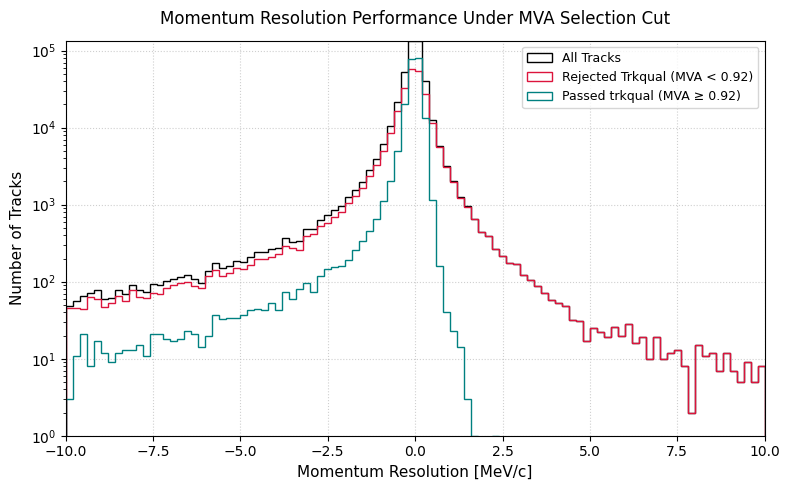

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# 2. Plot with explicit dataset labels 
ax.hist(mom_res, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), 
        log=True, histtype='step', color='black', label="All Tracks")

# Use :.2f to format the long floating point number to exactly 2 decimal places
ax.hist(mom_res[trkqual_prob < trkqual_cut], bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), 
        log=True, histtype='step', color='crimson', label=f"Rejected Trkqual (MVA < {trkqual_cut:.2f})")

ax.hist(mom_res[trkqual_prob >= trkqual_cut], bins=n_mom_res_bins, range=(min_mom_res, max_mom_res), 
        log=True, histtype='step', color='teal', label=f"Passed trkqual (MVA ≥ {trkqual_cut:.2f})")

# 3. Plot layout aesthetics
ax.legend(loc='upper right', fontsize=9)
ax.margins(0)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlabel("Momentum Resolution [MeV/c]", fontsize=11)
ax.set_ylabel("Number of Tracks", fontsize=11)
ax.set_title("Momentum Resolution Performance Under MVA Selection Cut", fontsize=12, pad=12)

plt.tight_layout()
plt.show()

In [ ]:
'''qualities = [ high_qual, low_qual ]
qual_labels = ["high", "low"]

xs = np.linspace(0,n_input_vars-1,n_input_vars)
ys = xs
x_corrs=[]
y_corrs=[]
corrs=[]#np.ndarray((n_input_vars,n_input_vars))
for qual_label,quality in zip(qual_labels,qualities):
    for i_x,x in enumerate(xs):
        x_i = input_dataset[:,i_x][quality]
        mean_x = np.mean(x_i)
        for i_y,y in enumerate(ys):
            if qual_label=="high":
                if (y<x):
                    continue
            elif qual_label=="low":
                if (y>=x):
                    continue
            y_i = input_dataset[:,i_y][quality]
            mean_y = np.mean(y_i)
            corr =  ( np.sum((x_i-mean_x)*(y_i - mean_y)) ) / ((np.sqrt(np.sum((x_i-mean_x)**2)))*(np.sqrt(np.sum((y_i-mean_y)**2))))
            x_corrs.append(x+0.5)
            y_corrs.append(y+0.5)
            corrs.append(corr)

H, xedges, yedges = np.histogram2d(x_corrs, y_corrs, bins=np.linspace(0,n_input_vars,n_input_vars+1), weights=corrs)
X, Y = np.meshgrid(xedges, yedges)
heatmap = plt.pcolormesh(Y, X, H, cmap='coolwarm')
cbar = plt.colorbar(heatmap)
plt.clim(-1,1)
_ = plt.xticks(xs+0.5, input_var_names)
_ = plt.yticks(ys+0.5, input_var_names)
cbar.ax.set_ylabel("Pearson correlation coefficient")
#print(yedges[:-1])
for x,y,corr in zip(x_corrs,y_corrs,corrs):
    if (abs(corr)>0.0):
        plt.text(x, y, '%.2f' % corr,
                 horizontalalignment='center',
                 verticalalignment='center',
                 )
plt.text(0.5, 7.1, "high-quality tracks", fontsize='large', fontweight='bold')#, horizontalalignment='center')#, rotation=45)
plt.text(7.1, 0.5, "low-quality tracks", fontsize='large', fontweight='bold', rotation=-90)#, verticalalignment='center', rotation=-90)
'''

'qualities = [ high_qual, low_qual ]\nqual_labels = ["high", "low"]\n\nxs = np.linspace(0,n_input_vars-1,n_input_vars)\nys = xs\nx_corrs=[]\ny_corrs=[]\ncorrs=[]#np.ndarray((n_input_vars,n_input_vars))\nfor qual_label,quality in zip(qual_labels,qualities):\n    for i_x,x in enumerate(xs):\n        x_i = input_dataset[:,i_x][quality]\n        mean_x = np.mean(x_i)\n        for i_y,y in enumerate(ys):\n            if qual_label=="high":\n                if (y<x):\n                    continue\n            elif qual_label=="low":\n                if (y>=x):\n                    continue\n            y_i = input_dataset[:,i_y][quality]\n            mean_y = np.mean(y_i)\n            corr =  ( np.sum((x_i-mean_x)*(y_i - mean_y)) ) / ((np.sqrt(np.sum((x_i-mean_x)**2)))*(np.sqrt(np.sum((y_i-mean_y)**2))))\n            x_corrs.append(x+0.5)\n            y_corrs.append(y+0.5)\n            corrs.append(corr)\n\nH, xedges, yedges = np.histogram2d(x_corrs, y_corrs, bins=np.linspace(0,n_input_vars,

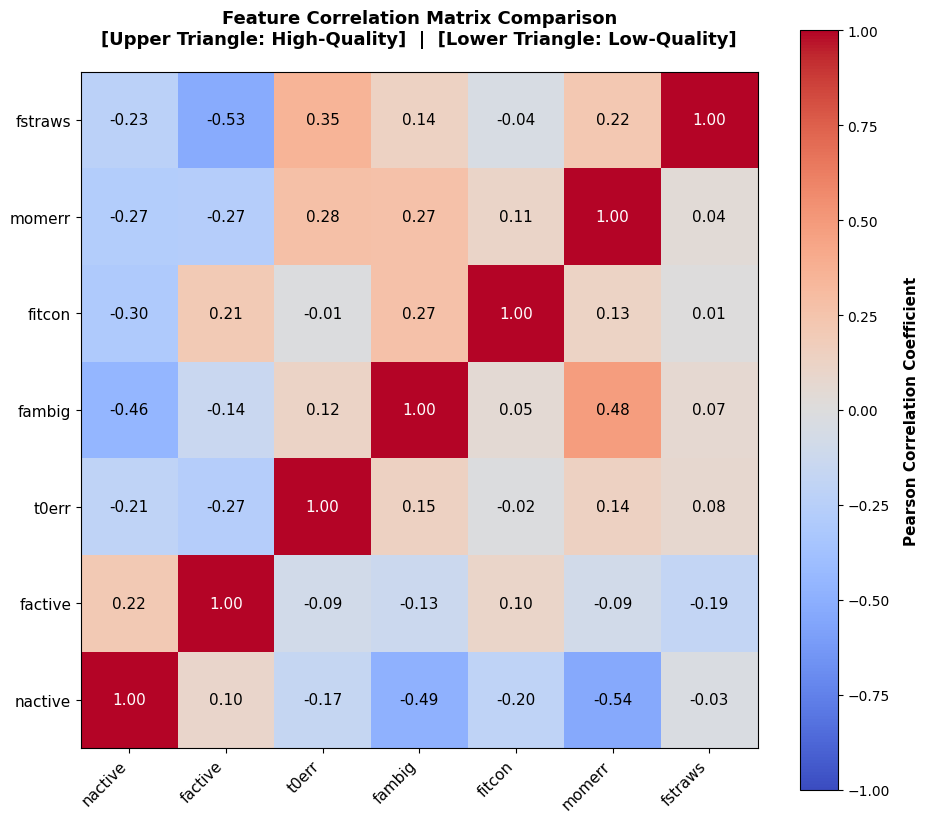

In [ ]:
# 1. Pull features and calculate exact Pearson coefficients
input_var_names = ["nactive", "factive", "t0err", "fambig", "fitcon", "momerr", "fstraws"]
n_vars = len(input_var_names)

corr_high = np.corrcoef(input_dataset[high_qual], rowvar=False)
corr_low  = np.corrcoef(input_dataset[low_qual],  rowvar=False)

# 2. Build the split matrix cleanly
combined_corr = np.zeros((n_vars, n_vars))
for i in range(n_vars):
    for j in range(n_vars):
        if i == j:
            combined_corr[i, j] = 1.0
        elif i < j:
            combined_corr[i, j] = corr_high[i, j]  # Upper Triangle
        else:
            combined_corr[i, j] = corr_low[i, j]   # Lower Triangle

# 3. Plot the grid setup
fig, ax = plt.subplots(figsize=(9.5, 8.5))
heatmap = ax.pcolormesh(np.arange(n_vars+1), np.arange(n_vars+1), combined_corr, cmap='coolwarm', vmin=-1.0, vmax=1.0)

# Add clear colorbar
cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label("Pearson Correlation Coefficient", fontsize=11, fontweight='bold', labelpad=10)

# Clean, explicit axis tick placement
ax.set_xticks(np.arange(n_vars) + 0.5)
ax.set_yticks(np.arange(n_vars) + 0.5)
ax.set_xticklabels(input_var_names, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(input_var_names, fontsize=11)
ax.set_aspect('equal')

# 4. FIXED: Correctly match matrix row/column tracking to the text overlays
for row in range(n_vars):
    for col in range(n_vars):
        val = combined_corr[row, col]
        # Dynamically switch text color (white for deep red/blue, black for lighter squares)
        text_color = 'white' if abs(val) > 0.55 else 'black'
        ax.text(col + 0.5, row + 0.5, f"{val:.2f}", ha='center', va='center', color=text_color, fontsize=11)

# FIXED: Re-positioned the descriptive text completely off the grid data squares
ax.set_title("Feature Correlation Matrix Comparison\n[Upper Triangle: High-Quality]  |  [Lower Triangle: Low-Quality]", 
             fontsize=13, fontweight='bold', pad=20, color='black')

plt.tight_layout()
plt.show()

In [ ]:
'''
# Write out all histograms and plots to a ROOT file for future reference
outfile = uproot.recreate(output_modelname+"_plots.root")

# Momentum resolution plots
mom_res_hist_all = np.histogram(mom_res, bins=n_mom_res_bins, range=(min_mom_res,max_mom_res))
outfile["all_mom_res"] = mom_res_hist_all
mom_res_hist_high_qual = np.histogram(mom_res[high_qual], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res))
outfile["high_qual_mom"] = mom_res_hist_high_qual
mom_res_hist_low_qual = np.histogram(mom_res[low_qual], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res))
outfile["low_qual_mom_res"] = mom_res_hist_low_qual
mom_res_hist_pass = np.histogram(mom_res[(trkqual>=trkqual_cut)], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res))
outfile["pass_mom_res"] = mom_res_hist_pass
mom_res_hist_fail = np.histogram(mom_res[(trkqual<trkqual_cut)], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res))
outfile["fail_mom_res"] = mom_res_hist_fail

# datasets (input, train, text, and valid)
datasets=[input_dataset, input_dataset, input_dataset, x_train, x_test, x_valid, input_dataset, input_dataset]
prefixes = ["all_", "high_qual_", "low_qual_", "train_", "test_", "valid_", "pass_", "fail_"]
cuts = [(), (high_qual), (low_qual), (), (), (), (trkqual>=trkqual_cut), (trkqual<trkqual_cut)]
# Feature histograms
for dataset,prefix,cut in zip(datasets, prefixes, cuts):
    for i_var in range(0, n_input_vars):
        feature_all = np.histogram(dataset[:,i_var][cut], bins=100, range=(x_mins[i_var],x_maxs[i_var]))
        outfile[prefix+"feature"+str(i_var)+"_"+input_var_names[i_var]] = feature_all
        feature_norm_all = np.histogram(dataset[:,i_var][cut], bins=100, range=(x_mins[i_var],x_maxs[i_var]), density=True)
        outfile[prefix+"feature"+str(i_var)+"_"+input_var_names[i_var]+"_norm"] = feature_norm_all
import pandas as pd
df = pd.DataFrame({"tpr" : tpr_keras, "fpr" : fpr_keras, "thresh" : thresholds_keras})
outfile["roc_curve"] = df '''
#outfile["corr_matrix"] = H,xedges,yedges (Use if I used Andy version of the heat map code)

'\n# Write out all histograms and plots to a ROOT file for future reference\noutfile = uproot.recreate(output_modelname+"_plots.root")\n\n# Momentum resolution plots\nmom_res_hist_all = np.histogram(mom_res, bins=n_mom_res_bins, range=(min_mom_res,max_mom_res))\noutfile["all_mom_res"] = mom_res_hist_all\nmom_res_hist_high_qual = np.histogram(mom_res[high_qual], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res))\noutfile["high_qual_mom"] = mom_res_hist_high_qual\nmom_res_hist_low_qual = np.histogram(mom_res[low_qual], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res))\noutfile["low_qual_mom_res"] = mom_res_hist_low_qual\nmom_res_hist_pass = np.histogram(mom_res[(trkqual>=trkqual_cut)], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res))\noutfile["pass_mom_res"] = mom_res_hist_pass\nmom_res_hist_fail = np.histogram(mom_res[(trkqual<trkqual_cut)], bins=n_mom_res_bins, range=(min_mom_res,max_mom_res))\noutfile["fail_mom_res"] = mom_res_hist_fail\n\n# datasets (input, train, text, a

In [ ]:
# 1. Initialize your structured ROOT export file
output_root_name = f"{output_modelname}_plots.root"

with uproot.recreate(output_root_name) as outfile:

    # SECTION A: MOMENTUM RESOLUTION HISTOGRAMS 
    outfile["all_mom_res"] = np.histogram(
        mom_res, bins=n_mom_res_bins, range=(min_mom_res, max_mom_res)
    )
    outfile["high_qual_mom_res"] = np.histogram(
        mom_res[high_qual], bins=n_mom_res_bins, range=(min_mom_res, max_mom_res)
    )
    outfile["low_qual_mom_res"] = np.histogram(
        mom_res[low_qual], bins=n_mom_res_bins, range=(min_mom_res, max_mom_res)
    )

    # Use continuous MVA score cut
    outfile["pass_mom_res"] = np.histogram(
        mom_res[trkqual_prob >= trkqual_cut], bins=n_mom_res_bins, range=(min_mom_res, max_mom_res)
    )
    outfile["fail_mom_res"] = np.histogram(
        mom_res[trkqual_prob < trkqual_cut], bins=n_mom_res_bins, range=(min_mom_res, max_mom_res)
    )

    # SECTION B: FEATURE HISTOGRAMS (all / high / low)
    for i_var, name in enumerate(input_var_names):
        feature_all = input_dataset[:, i_var]
        f_min, f_max = float(np.min(feature_all)), float(np.max(feature_all))

        feature_high = input_dataset[high_qual, i_var]
        feature_low  = input_dataset[low_qual, i_var]

        # all
        outfile[f"all_feature_{i_var}_{name}"] = np.histogram(feature_all, bins=100, range=(f_min, f_max))
        outfile[f"all_feature_{i_var}_{name}_norm"] = np.histogram(feature_all, bins=100, range=(f_min, f_max), density=True)

        # high quality
        outfile[f"high_qual_feature_{i_var}_{name}"] = np.histogram(feature_high, bins=100, range=(f_min, f_max))
        outfile[f"high_qual_feature_{i_var}_{name}_norm"] = np.histogram(feature_high, bins=100, range=(f_min, f_max), density=True)

        # low quality  
        outfile[f"low_qual_feature_{i_var}_{name}"] = np.histogram(feature_low, bins=100, range=(f_min, f_max))
        outfile[f"low_qual_feature_{i_var}_{name}_norm"] = np.histogram(feature_low, bins=100, range=(f_min, f_max), density=True)

    # SECTION C: ROC CURVE 
    df_roc = pd.DataFrame({"tpr": tpr, "fpr": fpr, "thresh": thresholds})
    outfile["roc_curve"] = df_roc

    # SECTION D: CORRELATION MATRIX
    # Try dict-style first; fallback to DataFrame if needed
    try:
        outfile["corr_matrix"] = {"correlation_coefficients": combined_corr}
    except Exception as e:
        print(f"[warn] dict-style corr_matrix write failed: {e}")
        corr_df = pd.DataFrame(combined_corr, columns=input_var_names, index=input_var_names)
        outfile["corr_matrix_df"] = corr_df

print(f"All research distributions safely archived inside: {output_root_name}")

All research distributions safely archived inside: TrkQual_xgb_v2.0_plots.root


### Saving the model as a .joblib file for the Mu2e offline pipeline work.

In [ ]:
# Inspect the model object
print(type(best_model))
print(dir(best_model))

# If it's a Pipeline, check its steps
if hasattr(best_model, 'steps'):
    print("\nPipeline steps:")
    for name, step in best_model.steps:
        print(f"  {name}: {type(step)}")

# If it's a Pipeline, the XGBoost classifier is usually the last step
if hasattr(best_model, 'named_steps'):
    for name, step in best_model.named_steps.items():
        print(f"\nStep '{name}' type: {type(step)}")
        if hasattr(step, 'save_model'):
            print(f"  --> XGBoost found at step '{name}'!")
            step.save_model(f"mu2e_project/trkQual_model.json")
            print("Saved!")

<class 'xgboost.sklearn.XGBClassifier'>
['_Booster', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__sklearn_is_fitted__', '__sklearn_tags__', '__str__', '__subclasshook__', '__weakref__', '_build_request_for_signature', '_can_use_inplace_predict', '_check_feature_names', '_check_n_features', '_configure_fit', '_create_dmatrix', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_estimator_type', '_get_default_requests', '_get_doc_link', '_get_iteration_range', '_get_metadata_request', '_get_param_names', '_get_tags', '_get_type', '_load_model_attributes', '_more_tags', '_repr_html_', '_repr_html_inner', '_repr_mimebundle_', '_set_evaluation_result', '_update_s